In [9]:
%load_ext autoreload
%autoreload 2

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

In [12]:
from CustomTree.customTree import CustomDecisionTree
from CustomTree.decisionTreeToCustomTreeParser import sklearn_tree_to_custom_tree, copy_custom_tree
# from CustomTree.graphicallyShowingTree import visualize_custom_tree #, plot_tree_partitions, plot_tree_partitions_2d_rectangles
from CustomTree.quadratic_constraint_optimization import gurobi_minimax, predict_with_minmax_model
from CustomTree.custom_tree_pruning import global_greedy_prune, global_greedy_prune_with_custom_cost, get_custom_cost_function

In [13]:
from Visualization.graphicallyShowingTree import visualize_custom_tree
from Visualization.partition_plot_matplotlib import plot_tree_partitions, plot_tree_partitions_2d_rectangles
from Visualization.partition_plot_matplotlib import plot_tree_partitions_3d_scatter, plot_tree_partitions_3d_cubes
from Visualization.partition_plot_plotly import plot_tree_partitions_plotly

In [14]:
from CustomTree.evaluationMethods import normalized_root_mean_square_error, mean_absolute_error

In [15]:
from CustomTree.custom_tree_scenario_based_pruning import global_greedy_prune_with_scenario_cost, ensure_all_leaves_have_metrics, compute_d_eff_from_data



In [16]:

dataset_paths = {
    "Jet" : r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/jet/jet_10000/data_jet_10000.csv',
    # "Exponential": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/exp/exp_10000/data_exp_10000.csv',
    # "NL1": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/nl1/nl1_10000/data_nl1_10000.csv',
    # "NL2": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/nl2/nl2_10000/data_nl2_10000.csv',
    # "Tank": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/tank/tank_10000/data_tank_10000.csv',
    # "Steam" : r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/steam/steam_10000/data_steam_10000.csv',
    # "Navigation" : "/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/RegressionTreeWithRefinment/RegressionTreeRefinment/data_files/RandV_1_RandPosition/navigation_trejectory_dataset.csv",
}

# dataset_paths = {
#     # "Jet" : r'datasets/data_jet_10000.csv',
#     # "Exponential": r'datasets/data_exp_10000.csv',
#     # "NL1": r'datasets/data_nl1_10000.csv',
#     # "NL2": r'datasets/data_nl2_10000.csv',
#     # "Tank": r'datasets/data_tank_10000.csv',
#     # "Steam" : r'datasets/data_steam_10000.csv',
    
#     # "Navigation" : "/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/RegressionTreeWithRefinment/RegressionTreeRefinment/data_files/RandV_1_RandPosition/navigation_trejectory_dataset.csv",
# }



# Systems Experiment

System Name = Jet
Max Depth = 4
NRMSE Training using Tree = 0.04207267276611268
NRMSE Testing using Tree = 0.04393226181415314
Converting Decision Tree to Custom Tree
Number of Nodes = 31
Number of Leaves = 16
Depth of Tree = 4
Optimizing Original Leaves
[METRICS] computing metrics for leaf 4 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 5 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 7 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 8 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 11 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 12 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 14 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 15 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 19 (missing_h=True, missing_eps=True)
[METRICS] computing metrics for leaf 20 (missing_h=True, missing_eps=True)

KeyboardInterrupt: 

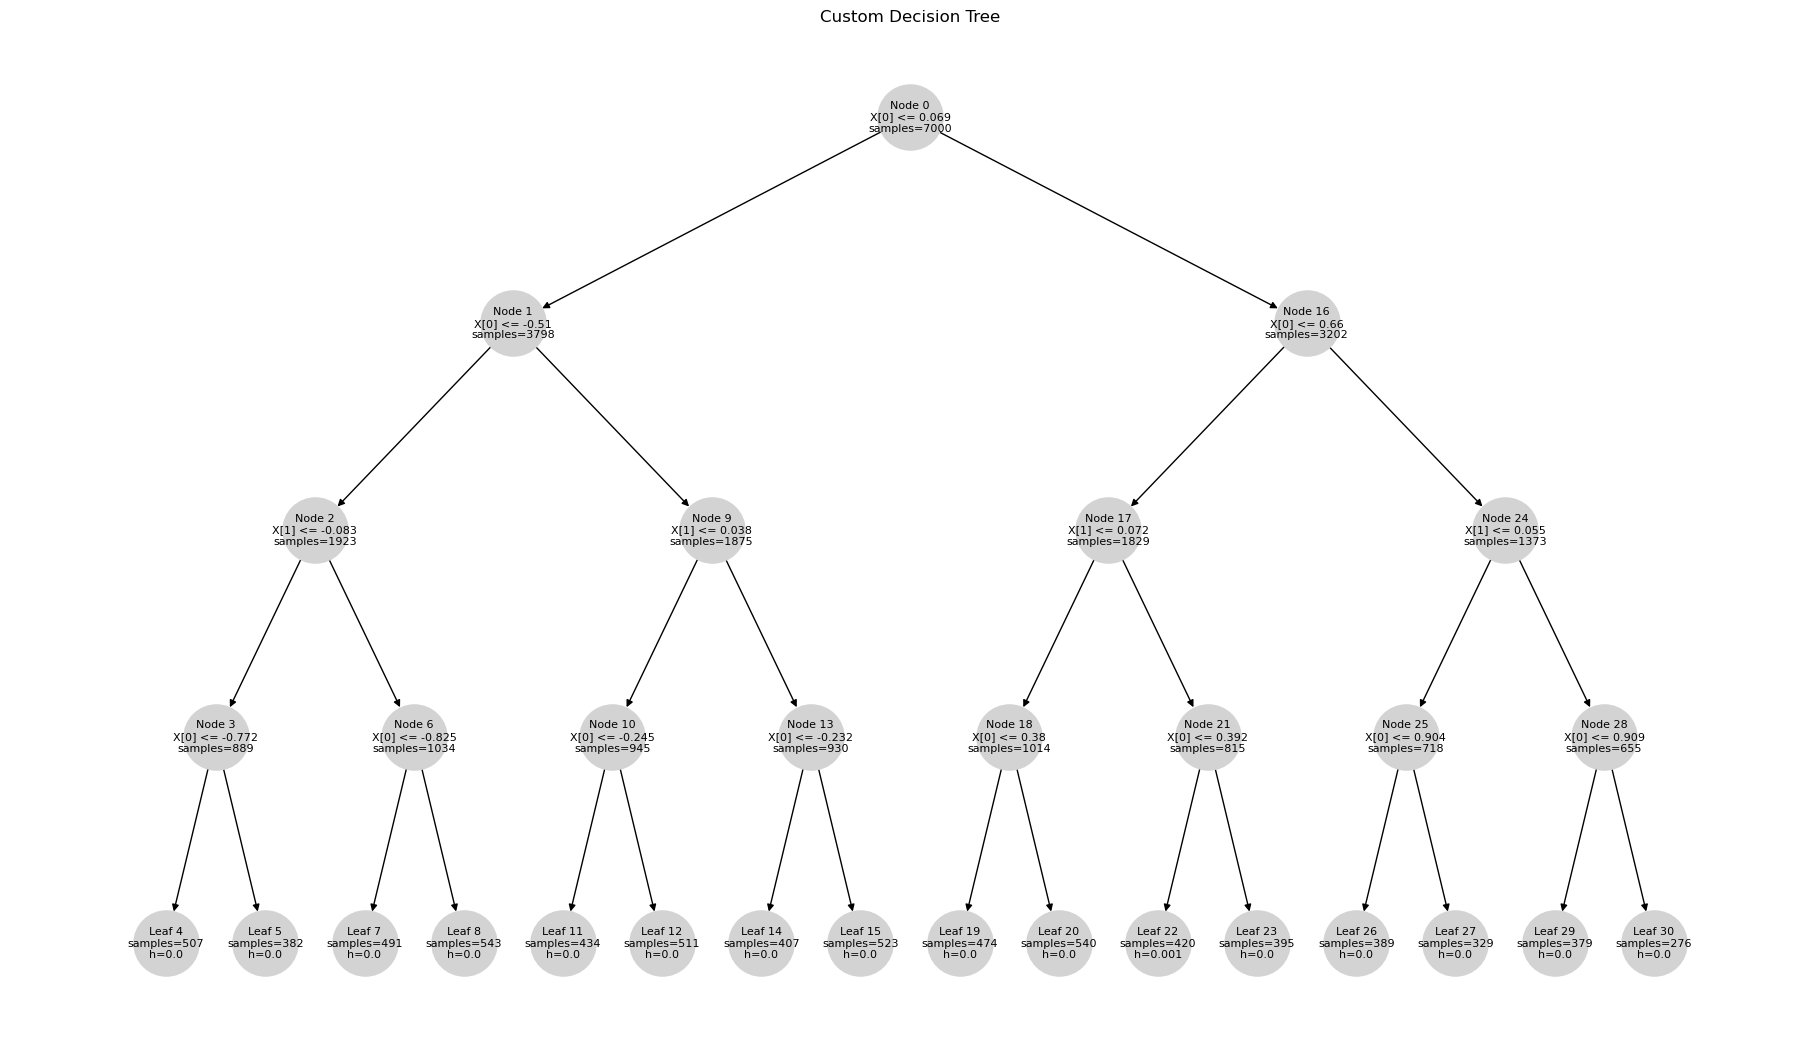

In [29]:

# Create a results list to accumulate all experiments
all_results = []

for system_name in dataset_paths:
    print(f"System Name = {system_name}")
    read_df = pd.read_csv(dataset_paths[system_name])
    read_df_dim = read_df.shape[1]
    X_attribute_count = int(read_df_dim/2)
    Y_class_count = int(read_df_dim/2)
    X_read = read_df.iloc[:, :X_attribute_count].values
    y_read = read_df.iloc[:, X_attribute_count:X_attribute_count + Y_class_count].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_read, y_read, test_size=0.3, random_state=42
    )
    
    max_depth_for_experiment = [ 4, 6, 8 ]#, 10, 15]
    for max_depth_item in max_depth_for_experiment:
        print(f"Max Depth = {max_depth_item}")
        dt_model_tree = DecisionTreeRegressor(
            max_depth= max_depth_item, 
            min_samples_leaf=1,
            random_state=42
        )
        
        dt_model_tree.fit(X_train, y_train)

        NRMSE_Train_Tree = normalized_root_mean_square_error(y_true=y_train, y_pred= dt_model_tree.predict(X_train))
        NRMSE_Test_Tree = normalized_root_mean_square_error(y_true=y_test, y_pred= dt_model_tree.predict(X_test))
        print(f"NRMSE Training using Tree = {NRMSE_Train_Tree}")
        print(f"NRMSE Testing using Tree = {NRMSE_Test_Tree}")


        print("Converting Decision Tree to Custom Tree")
        # Converting Decision Tree Regressor To Custom Tree
        custom_tree = sklearn_tree_to_custom_tree(dt_model_tree, X_train)
        print(f"Number of Nodes = {custom_tree.num_nodes()}\nNumber of Leaves = {custom_tree.num_leaves()}\nDepth of Tree = {custom_tree.compute_max_depth()}")
        print("Optimizing Original Leaves")
        # for leaf in custom_tree.get_leaves():
        #     M_val, m0_val, h_val = gurobi_minimax(
        #         X_train[leaf.sample_indices],
        #         y_train[leaf.sample_indices],
        #     )
        
        #     leaf.h = h_val
        #     leaf.M = M_val
        #     leaf.M_0 = m0_val
        beta = 1e-6
        d_eff = compute_d_eff_from_data(X_train, y_train, include_h=True)
        ensure_all_leaves_have_metrics(custom_tree, X_train, y_train, d_eff=d_eff, beta=beta, verbose=True)
        
        max_h_before = max([temp_leaf.h for temp_leaf in custom_tree.get_leaves()])
        min_h_before = min([temp_leaf.h for temp_leaf in custom_tree.get_leaves()])
        max_epsilon_before = max([temp_leaf.epsilon for temp_leaf in custom_tree.get_leaves()])
        min_epsilon_before = min([temp_leaf.epsilon for temp_leaf in custom_tree.get_leaves()])
        
        print("Evaluating The Affine Model Tree Before Pruning")
        NRMSE_Train_Affine_before = normalized_root_mean_square_error(y_true=y_train, y_pred= predict_with_minmax_model(custom_tree=custom_tree, X=X_train))
        NRMSE_Test_Affine_before = normalized_root_mean_square_error(y_true=y_test, y_pred= predict_with_minmax_model(custom_tree=custom_tree, X=X_test))
        print(f"NRMSE Training using Affine Before Pruning = {NRMSE_Train_Affine_before}")
        print(f"NRMSE Testing using Affine Before Pruning = {NRMSE_Test_Affine_before}")
        cost_functions = [ "scenario" ] #"basic", "average"]
        alphas = [0.001, 0.01, 0.05, 0.1, 0.5]
        for cost_function_item in cost_functions:
            print(f"Cost Function = {cost_function_item}")
            for alpha in alphas:
                print(f"Selected alpha value = {alpha}")
                tree_copy = copy_custom_tree(custom_tree)
                # cost_fn = get_custom_cost_function(alpha, cost_type=cost_function_item)
                print("BEFORE")
                nodes_before = tree_copy.num_nodes()
                print("nodes :", nodes_before)
                leaves_before = tree_copy.num_leaves()
                print("leaves:", leaves_before)
                depth_before = tree_copy.compute_max_depth()
                print("depth :", depth_before)
                # global_greedy_prune_with_custom_cost(tree_copy, X_train, y_train, cost_fn, plot_tree_each_iteration=False, alpha = alpha, verbose=False)
                global_greedy_prune_with_scenario_cost(
                    tree_copy,
                    X_train, y_train,
                    alpha=alpha,
                    d_eff= d_eff,
                    beta=beta,
                    plot_tree_each_iteration=False,
                    verbose=True,
                )
                print("\nAFTER")
                nodes_after = tree_copy.num_nodes()
                print("nodes :", nodes_after)
                leaves_after = tree_copy.num_leaves()
                print("leaves:", leaves_after)
                depth_after = tree_copy.compute_max_depth()
                print("depth :", depth_after)
                NRMSE_Train_Affine_after = normalized_root_mean_square_error(y_true=y_train, y_pred= predict_with_minmax_model(custom_tree=tree_copy, X=X_train))
                NRMSE_Test_Affine_after = normalized_root_mean_square_error(y_true=y_test, y_pred= predict_with_minmax_model(custom_tree=tree_copy, X=X_test))
                print(f"NRMSE Training using Tree = {NRMSE_Train_Affine_after}")
                print(f"NRMSE Testing using Tree = {NRMSE_Test_Affine_after}")

                max_h_after = max([temp_leaf.h for temp_leaf in tree_copy.get_leaves()])
                min_h_after = min([temp_leaf.h for temp_leaf in tree_copy.get_leaves()])
                max_epsilon_after = max([temp_leaf.epsilon for temp_leaf in tree_copy.get_leaves()])
                min_epsilon_after = min([temp_leaf.epsilon for temp_leaf in tree_copy.get_leaves()])
                
                if len(tree_copy.get_leaves()) > 1:
                    visualize_custom_tree(tree=tree_copy, save_path=f"graphs/trees/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png")
                    plot_tree_partitions_plotly(tree_copy, X_train, save_path=f"graphs/partitions/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png")
                # Save results
                all_results.append({
                    "system_name": system_name,
                    "max_depth": max_depth_item,
                    "cost_function": cost_function_item,
                    "alpha": alpha,
                    "nodes_before": nodes_before,
                    "leaves_before": leaves_before,
                    "depth_before": depth_before,
                    "nodes_after": nodes_after,
                    "leaves_after": leaves_after,
                    "depth_after": depth_after,
                    "NRMSE_Train_Tree": NRMSE_Train_Tree,
                    "NRMSE_Test_Tree": NRMSE_Test_Tree,
                    "NRMSE_Train_Affine_before": NRMSE_Train_Affine_before,
                    "NRMSE_Test_Affine_before": NRMSE_Test_Affine_before,
                    "NRMSE_Train_Affine_after": NRMSE_Train_Affine_after,
                    "NRMSE_Test_Affine_after": NRMSE_Test_Affine_after,
                    "Min_Epsilon_Before":min_epsilon_before,
                    "Max_Epsilon_Before":max_epsilon_before,
                    "Min_Epsilon_After":min_epsilon_after,
                    "Max_Epsilon_After":max_epsilon_after,
                    "Min_h_Before":min_h_before,
                    "Max_h_Before":max_h_before,
                    "Min_h_After":min_h_after,
                    "Max_h_After":max_h_after,
                    
                })

# Save all results to CSV and JSON for future analysis
results_df = pd.DataFrame(all_results)
results_csv_path = "custom_tree_experiments_results_EH_v1.csv"
# results_json_path = "custom_tree_experiments_results.json"

results_df.to_csv(results_csv_path, mode='a', index=False, header=False)
# results_df.to_json(results_json_path, orient="records", lines=True)

print(f"Results saved to {results_csv_path} ") # and {results_json_path}
                


In [212]:
print(f"Epsilon Before\nmin={min_epsilon_before} max={max_epsilon_before}\nEpsilon After\nmin={min_epsilon_after} max={max_epsilon_after}")
print(f"H Before\nmin={min_h_before} max={max_h_before}\nH After\nmin={min_h_after} max={max_h_after}")

Epsilon Before
min=0.0493314191699028 max=0.0952318087220192
Epsilon After
min=0.01974249631166458 max=0.0673188641667366
H Before
min=6.398303828482817e-07 max=0.0005632086559088031
H After
min=6.398303828482817e-07 max=0.0005632086559088031


In [172]:
for item in tree_copy.get_leaves():
    print(item.epsilon)

0.04457932633962717
0.08071491062307239
0.07298530592252035
0.09131571685697822
0.0775558143168856
0.09737351625535269
0.07577633100559951
0.08360974918972267
0.07339077984431212
0.09435957408554417
0.10033169902766721
0.02886454560519195


In [193]:
for item in tree_copy.get_leaves():
    print(item.epsilon)

0.03036241978406906
0.05444277077913284
0.0493314191699028
0.06141798943281174
0.052356354892253876
0.06538594514131546
0.05117952078580856
0.05635153502225876
0.049600087106227875
0.06341338902711868
0.0673188641667366
0.01974249631166458


In [195]:
for item in tree_copy.get_leaves():
    print(item.h)

0.00017883828670812814
6.398303828482817e-07
3.831344442731663e-05
6.654587217072976e-05
0.0002811544427487657
8.152837494436093e-05
0.0002410377740623342
0.0004964563372905506
0.0004962637630116564
0.0005632086559088031
0.0004061171392524297
0.004636671931030703


# Data Analysis

In [110]:
import pandas as pd

df = pd.read_csv("custom_tree_experiments_results_v5.csv")


print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   system_name                15 non-null     object 
 1   max_depth                  15 non-null     int64  
 2   cost_function              15 non-null     object 
 3   alpha                      15 non-null     float64
 4   nodes_before               15 non-null     int64  
 5   leaves_before              15 non-null     int64  
 6   depth_before               15 non-null     int64  
 7   nodes_after                15 non-null     int64  
 8   leaves_after               15 non-null     int64  
 9   depth_after                15 non-null     int64  
 10  NRMSE_Train_Tree           15 non-null     float64
 11  NRMSE_Test_Tree            15 non-null     float64
 12  NRMSE_Train_Affine_before  15 non-null     float64
 13  NRMSE_Test_Affine_before   15 non-null     float64
 

In [112]:
df.head(20)

,system_name,max_depth,cost_function,alpha,nodes_before,leaves_before,depth_before,nodes_after,leaves_after,depth_after,NRMSE_Train_Tree,NRMSE_Test_Tree,NRMSE_Train_Affine_before,NRMSE_Test_Affine_before,NRMSE_Train_Affine_after,NRMSE_Test_Affine_after
0,Jet,4,scenario,0.001,31,16,4,31,16,4,0.042073,0.043932,0.000863,0.000867,0.000863,0.000867
1,Jet,4,scenario,0.010,31,16,4,31,16,4,0.042073,0.043932,0.000863,0.000867,0.000863,0.000867
2,Jet,4,scenario,0.050,31,16,4,23,12,4,0.042073,0.043932,0.000863,0.000867,0.001847,0.001862
3,Jet,4,scenario,0.100,31,16,4,23,12,4,0.042073,0.043932,0.000863,0.000867,0.001847,0.001862
4,Jet,4,scenario,0.500,31,16,4,7,4,2,0.042073,0.043932,0.000863,0.000867,0.003348,0.003374
5,Jet,6,scenario,0.001,127,64,6,109,55,6,0.020639,0.022437,0.000237,0.000247,0.000380,0.000394
6,Jet,6,scenario,0.010,127,64,6,109,55,6,0.020639,0.022437,0.000237,0.000247,0.000380,0.000394
7,Jet,6,scenario,0.050,127,64,6,109,55,6,0.020639,0.022437,0.000237,0.000247,0.000380,0.000394
8,Jet,6,scenario,0.100,127,64,6,109,55,6,0.020639,0.022437,0.000237,0.000247,0.000380,0.000394
9,Jet,6,scenario,0.500,127,64,6,109,55,6,0.020639,0.022437,0.000237,0.000247,0.000380,0.000394


In [117]:
df[["system_name","max_depth", "alpha",  "leaves_before", "leaves_after", "NRMSE_Test_Affine_before", "NRMSE_Test_Affine_after" ]]

,system_name,max_depth,alpha,leaves_before,leaves_after,NRMSE_Test_Affine_before,NRMSE_Test_Affine_after
0,Jet,4,0.001,16,16,0.000867,0.000867
1,Jet,4,0.010,16,16,0.000867,0.000867
2,Jet,4,0.050,16,12,0.000867,0.001862
3,Jet,4,0.100,16,12,0.000867,0.001862
4,Jet,4,0.500,16,4,0.000867,0.003374
5,Jet,6,0.001,64,55,0.000247,0.000394
6,Jet,6,0.010,64,55,0.000247,0.000394
7,Jet,6,0.050,64,55,0.000247,0.000394
8,Jet,6,0.100,64,55,0.000247,0.000394
9,Jet,6,0.500,64,55,0.000247,0.000394


In [98]:
systems_in_csv = df["system_name"].unique()
systems_in_csv

array(['Jet'], dtype=object)

In [94]:
df[["max_depth", "cost_function", "alpha"]].drop_duplicates()


,max_depth,cost_function,alpha
0,4,basic,0.001
1,4,basic,0.010
2,4,basic,0.050
3,4,basic,0.100
4,4,basic,0.500
5,4,average,0.001
6,4,average,0.010
7,4,average,0.050
8,4,average,0.100
9,4,average,0.500


In [7]:
df["nodes_reduction"] = df["nodes_before"] - df["nodes_after"]
df["leaves_reduction"] = df["leaves_before"] - df["leaves_after"]

df["nodes_reduction_pct"] = df["nodes_reduction"] / df["nodes_before"]
df["leaves_reduction_pct"] = df["leaves_reduction"] / df["leaves_before"]

df["NRMSE_degradation"] = (
    df["NRMSE_Test_Affine_after"]
    - df["NRMSE_Test_Affine_before"]
)

df["NRMSE_vs_tree"] = (
    df["NRMSE_Test_Affine_after"]
    - df["NRMSE_Test_Tree"]
)


In [98]:
best_alpha = (
    df.loc[df.groupby(
        ["system_name", "max_depth", "cost_function"]
    )["NRMSE_Test_Affine_after"].idxmin()]
)

best_alpha[
    ["system_name", "max_depth", "cost_function",
     "alpha", "NRMSE_Test_Affine_after",
     "nodes_after", "leaves_after"]
]


,system_name,max_depth,cost_function,alpha,NRMSE_Test_Affine_after,nodes_after,leaves_after
35,Exponential,4,average,0.001,0.057129,27,14
30,Exponential,4,basic,0.001,0.057129,27,14
45,Exponential,6,average,0.001,0.023530,65,33
40,Exponential,6,basic,0.001,0.023364,87,44
55,Exponential,8,average,0.001,0.021047,71,36
50,Exponential,8,basic,0.001,0.014633,119,60
5,Jet,4,average,0.001,0.002297,13,7
0,Jet,4,basic,0.001,0.000946,25,13
15,Jet,6,average,0.001,0.002297,13,7
10,Jet,6,basic,0.001,0.000946,25,13


In [104]:
system = "Exponential"

sub = df[df.system_name == system]

sub = sub.sort_values("nodes_after")

sub[[
    "alpha",
    "cost_function",
    "nodes_after",
    "NRMSE_Test_Affine_after"
]]


,alpha,cost_function,nodes_after,NRMSE_Test_Affine_after
44,0.500,basic,1,0.154646
54,0.500,basic,1,0.154646
34,0.500,basic,1,0.154646
49,0.500,average,5,0.136591
39,0.500,average,5,0.136591
59,0.500,average,5,0.136591
38,0.100,average,11,0.061872
48,0.100,average,11,0.061872
58,0.100,average,11,0.061872
47,0.050,average,15,0.057648


In [31]:
# Plot: Alpha vs Test Error
# Accuracy degradation curve

import matplotlib.pyplot as plt

system = "Exponential"
depth = 4

sub = df[
    (df.system_name == system) &
    (df.max_depth == depth)
]

for cost in sub.cost_function.unique():
    tmp = sub[sub.cost_function == cost]

    plt.plot(
        tmp.alpha,
        tmp.NRMSE_Test_Affine_after,
        marker="o",
        label=cost
    )

plt.xlabel("Alpha")
plt.ylabel("NRMSE Test (After Pruning)")
# plt.xscale("log")
plt.title(f"{system} — depth={depth}")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'df' is not defined

In [33]:
# Plot: Nodes vs Error (Trade-off curve)
plt.figure()

for cost in sub.cost_function.unique():
    tmp = sub[sub.cost_function == cost]

    plt.scatter(
        tmp.nodes_after,
        tmp.NRMSE_Test_Affine_after,
        label=cost
    )

plt.xlabel("Nodes After Pruning")
plt.ylabel("NRMSE Test After")
plt.title(f"{system} Complexity–Accuracy Tradeoff")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'sub' is not defined

<Figure size 640x480 with 0 Axes>

In [69]:
#  Summary Table Per System
summary = (
    df.groupby(["system_name", "max_depth", "cost_function"])
      .agg(
          best_alpha=("alpha", lambda x: x.iloc[
              df.loc[x.index]["NRMSE_Test_Affine_after"].argmin()
          ]),
          min_test_error=("NRMSE_Test_Affine_after", "min"),
          min_nodes=("nodes_after", "min"),
          avg_nodes=("nodes_after", "mean"),
      )
      .reset_index()
)

summary


,system_name,max_depth,cost_function,best_alpha,min_test_error,min_nodes,avg_nodes
0,Jet,4,average,0.001,0.002297,3,5.4
1,Jet,4,basic,0.001,0.000946,3,8.6
2,Jet,6,average,0.001,0.002297,3,5.4
3,Jet,6,basic,0.001,0.000946,3,8.6
4,Jet,8,average,0.001,0.002297,3,5.4
5,Jet,8,basic,0.001,0.000946,3,8.6


In [71]:
# Ranking Cost Functions
df.groupby("cost_function")[
    ["nodes_reduction_pct", "NRMSE_degradation"]
].mean()


,nodes_reduction_pct,NRMSE_degradation
cost_function,,
average,0.924240,0.009169
basic,0.879345,0.006936
